# 03 - Historical Impact Analysis

Analyses historical flood severity across selected LGAs using Floodscan data and NIHSA flood records, computing return periods and exploring seasonal patterns and year-on-year trends.

No datasets are saved to Azure storage in this notebook.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

from src.datasources import nihsa, codab
from src.utils import rp_calc
from src.constants import *
import ocha_stratus as stratus
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from dotenv import load_dotenv
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

load_dotenv()

True

## Load data

In [3]:
df_floodscan = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet"
)
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas.parquet"
)
df_floodrecord = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/nihsa/floodhistory_2013_2023_sel_lgas.parquet"
)

In [4]:
df_floodrecord.Year.min()

np.int64(2013)

## Calculate return periods

In [5]:
df_floodscan["year"] = df_floodscan["valid_date"].dt.year
df_floodscan = df_floodscan[df_floodscan.year != 2026]

df_floodscan_max = df_floodscan.loc[
    df_floodscan.groupby(["pcode", "year"])["mean"].idxmax()
][["pcode", "year", "valid_date", "mean"]]

df_floodscan_rp = rp_calc.calculate_groups_rp(
    df_floodscan_max, by=["pcode"], col_name="mean", ascending=False
)

In [6]:
# Merge HA assignment and LGA names into the RP dataframe
df_floodscan_rp = df_floodscan_rp.merge(
    gdf_lga_sel[["ADM2_PCODE", "ADM2_EN", "HA_assigned"]],
    left_on="pcode",
    right_on="ADM2_PCODE",
    how="left",
)

# Sort by HA then by LGA name for grouped display
df_floodscan_rp_sorted = df_floodscan_rp.sort_values(
    ["HA_assigned", "ADM2_EN"]
)

# Create mapping from pcode to LGA name and HA
pcode_to_name = df_floodscan_rp_sorted.drop_duplicates("pcode").set_index(
    "pcode"
)["ADM2_EN"]
pcode_to_ha = df_floodscan_rp_sorted.drop_duplicates("pcode").set_index(
    "pcode"
)["HA_assigned"]

# Pivot the data with sorted pcodes
df_pivot = df_floodscan_rp_sorted.pivot(
    index="pcode", columns="year", values="mean_rp"
)

# Replace pcode index with LGA names
df_pivot.index = df_pivot.index.map(pcode_to_name)

## Create heatmap plot

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_28799/1011749105.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_reds = plt.cm.get_cmap("Reds")


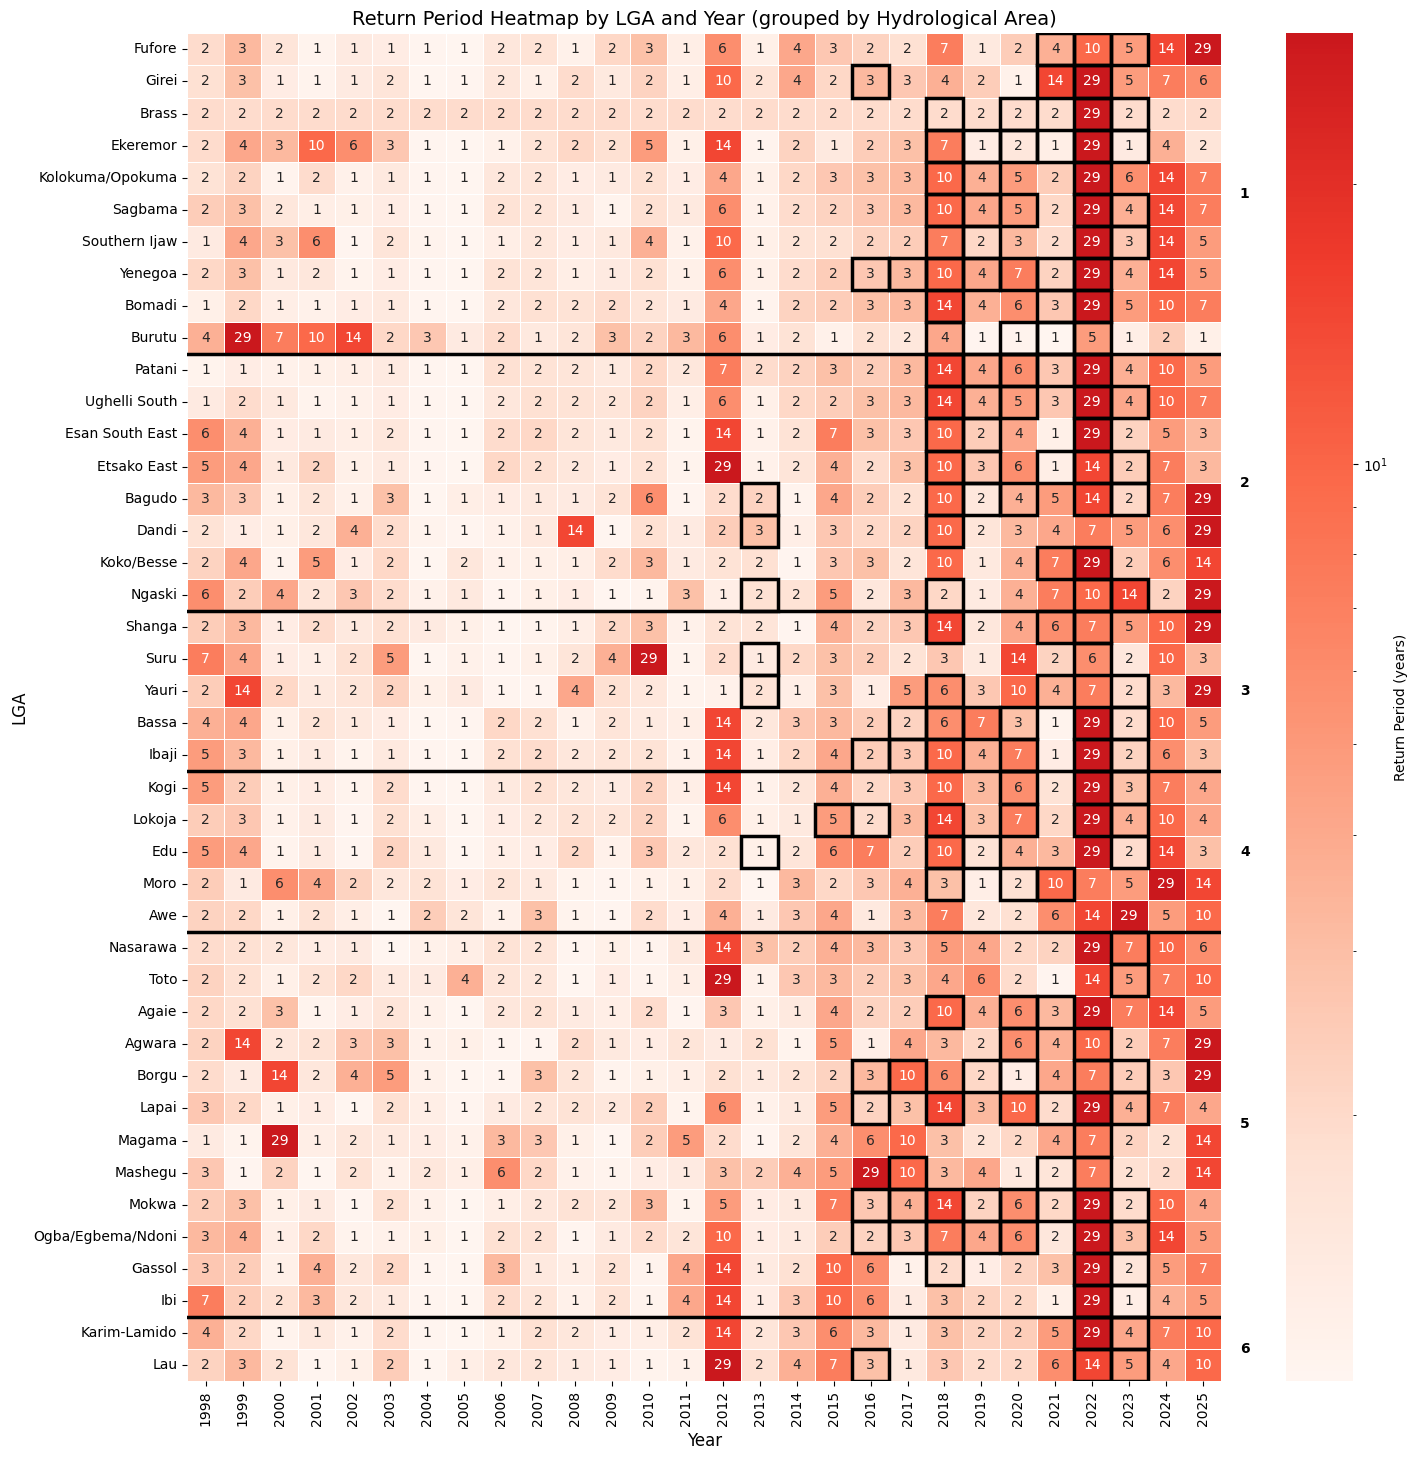

In [7]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(15, len(df_pivot) * 0.35))

# Set vmin to a small positive number to avoid log(0) issues
vmin = max(0.1, df_pivot.min().min())
vmax = df_pivot.max().max()

cmap_reds = plt.cm.get_cmap("Reds")
colors = cmap_reds(
    np.linspace(0, 0.75, 256)
)  # Use only 0-75% of the colormap range
cmap_light = ListedColormap(colors)

sns.heatmap(
    df_pivot,
    annot=True,
    fmt=".0f",
    cmap=cmap_light,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cbar_kws={"label": "Return Period (years)"},
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)

flooded_cells = set(
    df_floodrecord[df_floodrecord["Flooded"] == True][["ADM2_EN", "Year"]]
    .apply(tuple, axis=1)
    .values
)

# Add rectangles around flooded cells
for i, lga in enumerate(df_pivot.index):
    for j, year in enumerate(df_pivot.columns):
        if (lga, year) in flooded_cells:
            rect = Rectangle(
                (j, i),
                1,
                1,
                fill=False,
                edgecolor="black",
                linewidth=2.5,
                zorder=10,
            )
            ax.add_patch(rect)

# Add horizontal lines to separate hydrological areas
ha_groups = (
    df_floodscan_rp_sorted.drop_duplicates("pcode")
    .groupby("HA_assigned")
    .size()
    .cumsum()
)
for i, boundary in enumerate(ha_groups.values[:-1]):
    ax.axhline(y=boundary, color="black", linewidth=2.5)

# Add HA labels on the right side
y_positions = []
ha_names = []
prev_boundary = 0
for ha, boundary in ha_groups.items():
    y_pos = (prev_boundary + boundary) / 2
    y_positions.append(y_pos)
    ha_names.append(ha)
    prev_boundary = boundary

# Add HA labels as text annotations on the right
for y_pos, ha_name in zip(y_positions, ha_names):
    ax.text(
        len(df_pivot.columns) + 0.5,
        y_pos,
        ha_name,
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("LGA", fontsize=12)
ax.set_title(
    "Return Period Heatmap by LGA and Year (grouped by Hydrological Area)",
    fontsize=14,
)

plt.tight_layout()
plt.show()
# plt.savefig("figures/return_period_heatmap.png", dpi=300)

Total LGAs tracked: 44
Years with RP data: [np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Years with flood classification: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


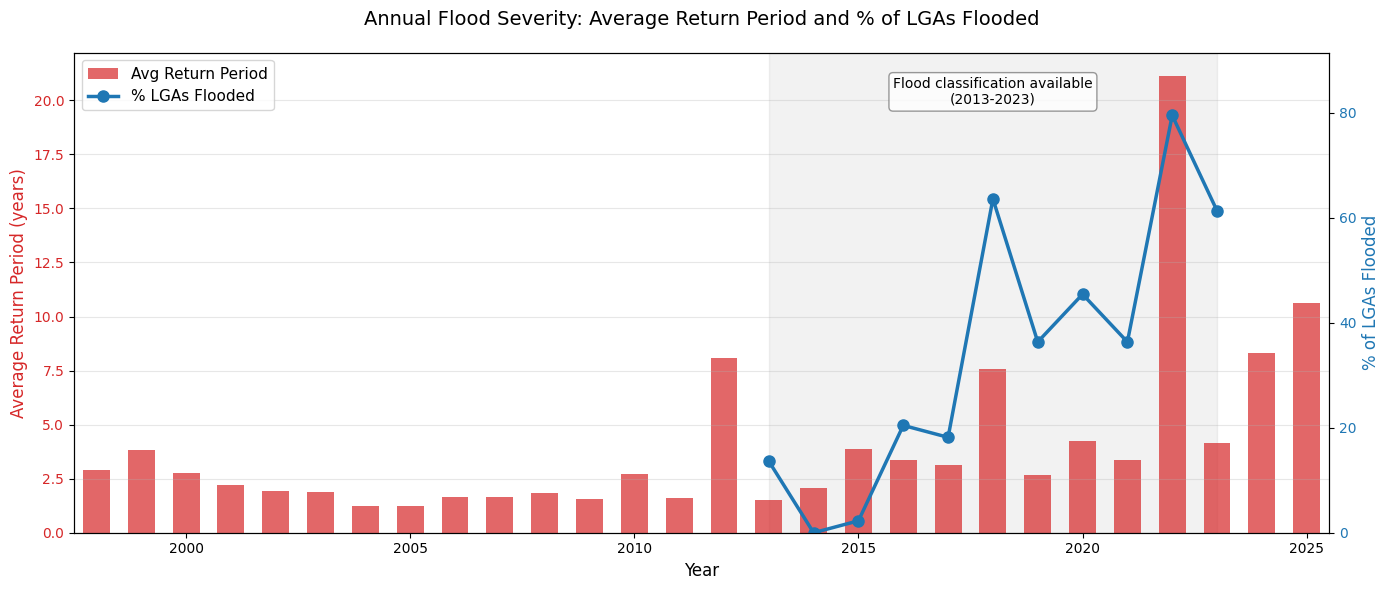

In [8]:
# Summary plot: Average RP per year + % Flooded LGAs
# Calculate average return period per year across all LGAs
avg_rp_per_year = (
    df_floodscan_rp.groupby("year")["mean_rp"].mean().reset_index()
)
avg_rp_per_year.columns = ["year", "avg_rp"]

# Calculate % of LGAs flooded per year (2013-2023 only)
total_lgas = df_floodrecord["ADM2_PCODE"].nunique()
pct_flooded_per_year = (
    df_floodrecord.groupby("Year")
    .agg({"Flooded": lambda x: (x.sum() / total_lgas) * 100})
    .reset_index()
)
pct_flooded_per_year.columns = ["year", "pct_flooded"]

print(f"Total LGAs tracked: {total_lgas}")
print(f"Years with RP data: {sorted(avg_rp_per_year['year'].unique())}")
print(
    f"Years with flood classification: {sorted(pct_flooded_per_year['year'].unique())}"
)

# Create dual y-axis plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Average return period as bars
color_bars = "#d62728"
ax1.bar(
    avg_rp_per_year["year"],
    avg_rp_per_year["avg_rp"],
    alpha=0.7,
    color=color_bars,
    label="Avg Return Period",
    width=0.6,
)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Average Return Period (years)", fontsize=12, color=color_bars)
ax1.tick_params(axis="y", labelcolor=color_bars)
ax1.grid(True, alpha=0.3, axis="y")

# Plot 2: % flooded LGAs as line on second y-axis
ax2 = ax1.twinx()
color_line = "#1f77b4"
ax2.plot(
    pct_flooded_per_year["year"],
    pct_flooded_per_year["pct_flooded"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=color_line,
    label="% LGAs Flooded",
)
ax2.set_ylabel("% of LGAs Flooded", fontsize=12, color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.set_ylim(0, max(pct_flooded_per_year["pct_flooded"]) * 1.15)

# Add shaded region for flood classification period
ax1.axvspan(2013, 2023, alpha=0.1, color="gray", zorder=0)
ax1.text(
    2018,
    ax1.get_ylim()[1] * 0.95,
    "Flood classification available\n(2013-2023)",
    ha="center",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"
    ),
)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=11)

ax1.set_title(
    "Annual Flood Severity: Average Return Period and % of LGAs Flooded",
    fontsize=14,
    pad=20,
)
ax1.set_xlim(
    avg_rp_per_year["year"].min() - 0.5, avg_rp_per_year["year"].max() + 0.5
)

plt.tight_layout()
plt.show()
# plt.savefig("figures/annual_flood_severity_summary.png", dpi=300)